In [1]:
# %pip install ipywidgets
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import seaborn as sns
sns.set_context('poster')
np.random.seed(1)

In [2]:
def true_function(X):
    return np.cos(1.5 * np.pi * X)

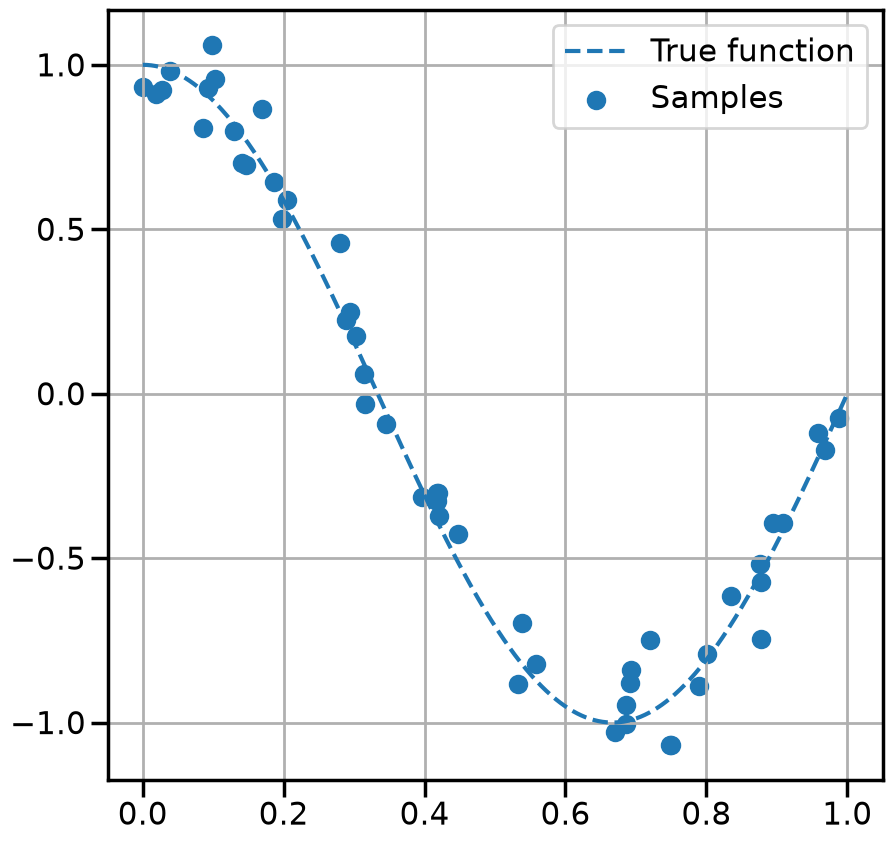

In [3]:


# Number of data points
n_samples = 50
N = 1000
X = np.linspace(0, 1, N).reshape(-1, 1)
# True Function we want to estimate

# Noisy Samples from the true function
x = np.sort(np.random.rand(n_samples)).reshape(-1, 1)
y = true_function(x) + np.random.normal(0, 0.1, n_samples).reshape(-1, 1)

plt.figure(figsize=(10,10))
# Plot the true function:

plt.plot(X, true_function(X), '--',label="True function")
# Plot the data samples
plt.scatter(x,y, label="Samples")
plt.legend(loc="best")
plt.grid()
plt.show()

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, test_size=0.2)
print('Training set size:', len(X_train))
print('Test set size:', len(X_test))
X_test_sorted = np.sort(X_test, axis=0)

Training set size: 40
Test set size: 10


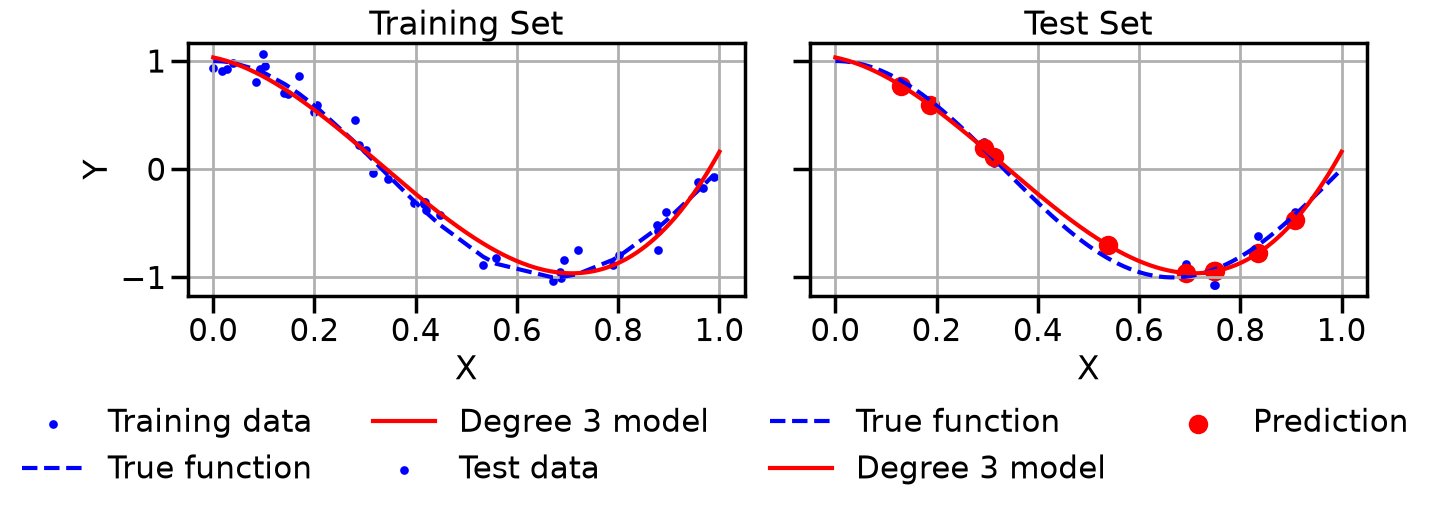

In [ ]:
degree = 4
model = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)
model.fit(X_train, Y_train)
y_pred = model.predict(X_test_sorted)
y_model = model.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Smooth x-values for drawing the learned polynomial curve
X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
y_plot = model.predict(X_plot)

training_index_sorted = np.argsort(X_train[:,0])
X_train_sorted = X_train[training_index_sorted]
Y_train_sorted = Y_train[training_index_sorted]

# Left: training data
axes[0].scatter(X_train, Y_train, color="blue", s=18, label="Training data")
axes[0].plot(X_train_sorted, true_function(X_train_sorted), "--", color="blue", label="True function")
axes[0].plot(X, model.predict(X), color="red", label=f"Degree {degree} model")
axes[0].set_title("Training Set")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].grid()

# Right: test data
axes[1].scatter(X_test, Y_test, color="blue", s=18, label="Test data")
axes[1].plot(X, true_function(X), "--", color="blue", label="True function")
axes[1].plot(X, model.predict(X), color="red", label=f"Degree {degree} model")
axes[1].scatter(X_test, model.predict(X_test), color="red", label="Prediction")
axes[1].set_title("Test Set")
axes[1].set_xlabel("X")
axes[1].grid()

handles0, labels0 = axes[0].get_legend_handles_labels()
handles1, labels1 = axes[1].get_legend_handles_labels()

fig.legend(
    handles0 + handles1,
    labels0 + labels1,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=4,
    frameon=False
)

plt.tight_layout(rect=[0, 0.10, 1, 1])

Text(0.5, 1.0, 'Polynomial Regression degree vs MSE (on testing set)')

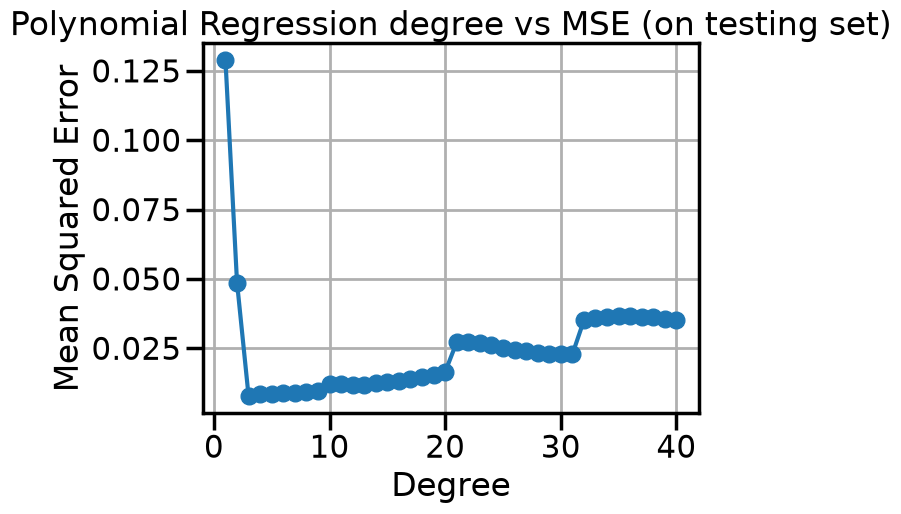

In [61]:
MSE_array = np.array([])
Degree_array = np.linspace(1, 40, 40).astype(int)
for degree in Degree_array:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    MSE = np.mean((y_pred - Y_test)**2)
    MSE_array = np.append(MSE_array, MSE)
plt.plot(Degree_array, MSE_array, 'o-')
plt.grid()
plt.xlabel('Degree')
plt.ylabel('Mean Squared Error')
plt.title('Polynomial Regression degree vs MSE (on testing set)')